In [1]:
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
import pandas as pd
import plotly.graph_objects as go

In [2]:
dataset_path = r"C:\Users\Abdo\Desktop\ABSA_Project\data\raw\restaurant_dataset.xml"

data_tree = ET.parse(dataset_path)

data_root = data_tree.getroot()

In [3]:
def parse_sentiment_data(root):
    data = []

    for sentence in root.findall("sentence"):
        text = sentence.find("text").text

        aspect_terms = sentence.find("aspectTerms")

        if aspect_terms is not None:
            for aspect in aspect_terms.findall("aspectTerm"):
                data.append({
                    "sentence": text,
                    "aspect": aspect.attrib["term"],
                    "sentiment": aspect.attrib["polarity"],
                    "from": int(aspect.attrib["from"]),
                    "to": int(aspect.attrib["to"])
                })

        else:
            continue

    return pd.DataFrame(data)

In [4]:
df = parse_sentiment_data(data_root)

df = df.drop_duplicates(subset=["sentence", "aspect"])

In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

In [6]:
train_df.shape, test_df.shape

((2924, 5), (731, 5))

In [7]:
train_df.head()

,sentence,aspect,sentiment,from,to
2309,I ordered tamarind duck and my wife ordered no...,dishes,positive,112,118
617,Pastrami or corned beef are juicy and piled hi...,rye bread,positive,64,73
3157,I had to ask her three times before she finall...,dish,neutral,67,71
815,"Unfortunately, the food was NOT something to g...",food,negative,19,23
3426,The service was great as well.,service,positive,4,11


In [8]:
for col in ['aspect', 'sentiment']:
    print(train_df[col].value_counts())
    print('-'*50)
    print(test_df[col].value_counts())
    print('-'*50)

aspect
food                      272
service                   166
place                      48
dinner                     46
menu                       46
                         ... 
lamb chettinad              1
after dinner drinks         1
special menu                1
water and wine glasses      1
pork buns                   1
Name: count, Length: 1090, dtype: int64
--------------------------------------------------
aspect
food                           72
service                        37
place                          15
prices                         13
sushi                          13
                               ..
green curry with vegetables     1
Gnocchi                         1
food spot                       1
quail                           1
fries                           1
Name: count, Length: 376, dtype: int64
--------------------------------------------------
sentiment
positive    1718
negative     631
neutral      503
conflict      72
Name: count, dtype: int

In [9]:
for sentence in train_df[train_df['sentiment'] == 'conflict']['sentence'].head(5):
    print(sentence)

The first time the sushi was outstanding, the second time it was a little bland.
The chicken parm was edible but had canned tomato sauce and boxed pasta and the chicken with portobello mushrooms consisted of dry, inedible chicken with terrible sauce.
Forget the rush and the wait and the noise (which isn't actually that bad), I mean please, who goes to a steakhouse to be coddled and romantic?
The service is spotty, sometimes really friendly and sometimes barely there.
There are a few Italian employees who may not speak the best English but for me that adds to the experience.


In [10]:
train_df = train_df[train_df["sentiment"] != "conflict"]
train_df = train_df.reset_index(drop=True)

test_df = test_df[test_df["sentiment"] != "conflict"]
test_df = test_df.reset_index(drop=True)

In [11]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2852 entries, 0 to 2851
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sentence   2852 non-null   str  
 1   aspect     2852 non-null   str  
 2   sentiment  2852 non-null   str  
 3   from       2852 non-null   int64
 4   to         2852 non-null   int64
dtypes: int64(2), str(3)
memory usage: 427.0 KB


In [12]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 713 entries, 0 to 712
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sentence   713 non-null    str  
 1   aspect     713 non-null    str  
 2   sentiment  713 non-null    str  
 3   from       713 non-null    int64
 4   to         713 non-null    int64
dtypes: int64(2), str(3)
memory usage: 103.9 KB


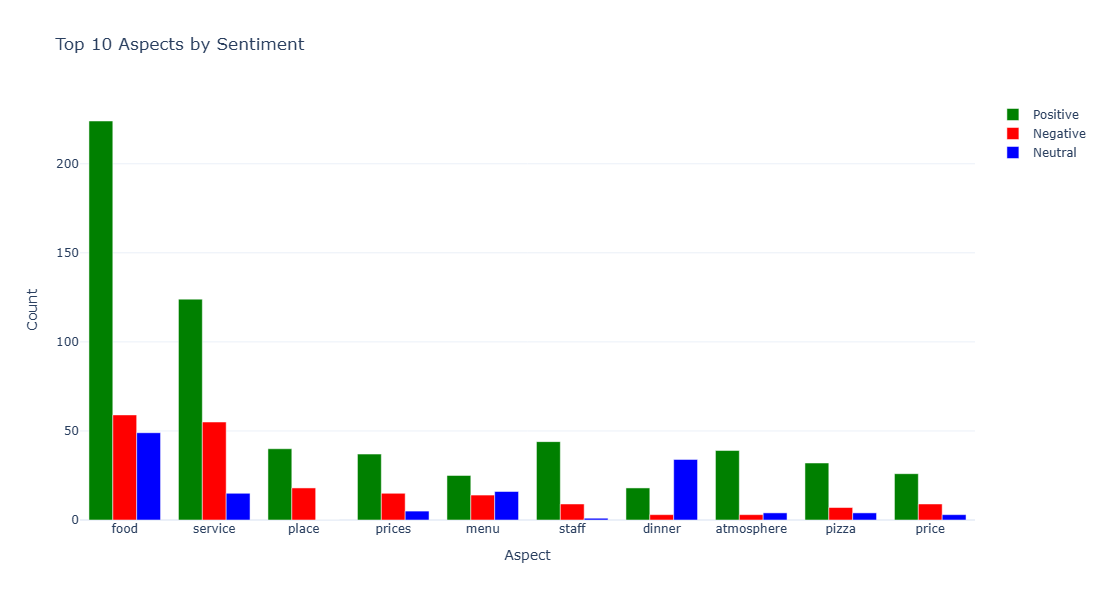

In [13]:
top_aspects = df["aspect"].value_counts().head(10).index

filtered_df = df[df["aspect"].isin(top_aspects)]

aspect_sentiment_counts = (
    filtered_df
    .groupby(["aspect", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(top_aspects)
)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=aspect_sentiment_counts.index,
    y=aspect_sentiment_counts["positive"],
    name="Positive",
    marker_color="green"
))

fig.add_trace(go.Bar(
    x=aspect_sentiment_counts.index,
    y=aspect_sentiment_counts["negative"],
    name="Negative",
    marker_color="red"
))

fig.add_trace(go.Bar(
    x=aspect_sentiment_counts.index,
    y=aspect_sentiment_counts["neutral"],
    name="Neutral",
    marker_color="blue"
))

fig.update_layout(
    title="Top 10 Aspects by Sentiment",
    xaxis_title="Aspect",
    yaxis_title="Count",
    barmode="group",
    template="plotly_white",
    width=1100,
    height=600
)

fig.show()

In [14]:
train_df.to_csv(r"C:\Users\Abdo\Desktop\ABSA_Project\data\processed\train_sentiment.csv", index=False)
test_df.to_csv(r"C:\Users\Abdo\Desktop\ABSA_Project\data\processed\test_sentiment.csv", index=False)